# Unit 1 — REINFORCE: Policy Gradients from Scratch

> *Part of the [RL for Robotics & LLMs](https://github.com/AliBuildsAI/rl-for-robotics-llms) series.*

In this notebook we build **REINFORCE** completely from scratch in PyTorch and
train it on CartPole-v1.

REINFORCE is the original policy gradient algorithm (Williams, 1992) and the
conceptual ancestor of everything modern: PPO, A3C, RLHF, and GRPO all build
directly on top of this one idea.

By the end you will have:
- A trained agent that balances the pole for 500 steps
- An animated GIF of the trained agent
- Solid intuition for *why* the math works — not just what the code does


In [1]:
%pip install -q "gymnasium[classic-control]" imageio pillow matplotlib torch
print("All packages ready.")



[notice] A new release of pip is available: 25.0 -> 26.1.1
[notice] To update, run: python3.13 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
All packages ready.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio
from IPython.display import Image, display

print(f"gymnasium {gym.__version__}  |  torch {torch.__version__}")


gymnasium 1.3.0  |  torch 2.12.0


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


---
## 1  The Environment — CartPole-v1

CartPole is the "Hello World" of RL. A pole is attached to a cart on a
frictionless track. The agent must keep the pole upright by pushing the cart
left or right.

**State** (4 floats):

| Index | Variable | Meaning |
|-------|----------|---------|
| 0 | `x` | Cart position |
| 1 | `ẋ` | Cart velocity |
| 2 | `θ` | Pole angle (radians) |
| 3 | `θ̇` | Pole angular velocity |

**Actions**: 0 = push left, 1 = push right

**Reward**: +1 for every timestep the pole stays up.
**Done** when the pole tips past ±12° or the cart moves off-screen.

The episode is **solved** when the agent averages ≥475 reward over 100
consecutive episodes (i.e. it holds the pole up for essentially the full 500-step
episode limit).


---
## 2  The Big Idea — What is a Policy Gradient?

In supervised learning we have labelled data and minimise a loss.
In RL we have **no labels** — only a delayed reward signal.

The core insight:

> **If an action led to high reward → make it more likely.
> If an action led to low reward → make it less likely.**

We represent the policy as a neural network $\pi_\theta(a \mid s)$ that outputs
a probability distribution over actions given a state.  We want to find
parameters $\theta$ that maximise the expected total reward:

$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_{t=0}^{T} r_t\right]$$

### The Policy Gradient Theorem

Taking the gradient of $J$ (Williams 1992 / Sutton et al. 1999):

$$\nabla_\theta J(\theta)
= \mathbb{E}_{\tau \sim \pi_\theta}\left[
    \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t \mid s_t) \cdot G_t
  \right]$$

where $G_t$ is the **return** (total discounted reward from step $t$ onward).

Two things to notice:
1. We need $\log \pi$ not $\pi$ — this comes from the log-derivative trick:
   $\nabla \log f = \nabla f / f$.
2. We can estimate the expectation by running episodes and averaging.

In practice we **ascend** this gradient with SGD — but PyTorch minimises by
default, so we flip the sign and minimise $-\log \pi_\theta(a_t \mid s_t) \cdot G_t$.


---
## 3  The Policy Network

We use a small two-hidden-layer MLP.  The output is a **softmax** over actions
— so it always outputs a valid probability distribution.

```
state (4,) → Linear → ReLU → Linear → ReLU → Linear → Softmax → probs (2,)
```


In [4]:
class PolicyNetwork(nn.Module):
    """
    Maps state → action probability distribution.

    Input:  state vector  (state_dim,)          e.g. (4,) for CartPole
    Output: action probs  (action_dim,)          e.g. (2,) — sums to 1
    """

    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),   # (4,) → (128,)
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),  # (128,) → (128,)
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),  # (128,) → (2,)  raw logits
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (state_dim,) or (batch, state_dim)
        # returns: (action_dim,) or (batch, action_dim)  — probabilities
        return torch.softmax(self.net(x), dim=-1)

    def select_action(self, state: np.ndarray):
        """
        Sample an action from the policy distribution.

        Returns
        -------
        action   : int       — the sampled action
        log_prob : Tensor()  — log π(action | state), scalar, kept in graph
        """
        # Convert numpy state to a float32 tensor on the right device
        state_t = torch.as_tensor(state, dtype=torch.float32, device=device)
        # state_t: (4,)

        probs = self.forward(state_t)
        # probs: (2,)  — e.g. [0.6, 0.4]

        # Categorical distribution lets us sample + compute log_prob in one go
        dist   = torch.distributions.Categorical(probs)
        action = dist.sample()
        # action: Tensor scalar, e.g. tensor(1)

        return action.item(), dist.log_prob(action)
        # log_prob is a scalar Tensor with grad_fn — PyTorch tracks this
        # for backprop later


---
## 4  Reward-to-Go and Normalisation

### Why reward-to-go instead of total episode reward?

The full episode return $G = \sum_t r_t$ includes rewards from *before* step
$t$ — but actions at step $t$ can't influence the past.  Using only the
**future** return (reward-to-go) reduces variance without adding bias:

$$G_t = \sum_{t'=t}^{T} \gamma^{t'-t}\, r_{t'}$$

$\gamma \in [0,1)$ is the discount factor — it down-weights far-future rewards
(slight myopia that also helps convergence).

### Why normalise?

Early in training $G_t$ can have huge variance (some episodes are short, some
long).  Subtracting the mean and dividing by the standard deviation keeps the
gradient updates in a stable range:

$$\hat{G}_t = \frac{G_t - \mu_G}{\sigma_G + \epsilon}$$

This is analogous to batch normalisation — same practical benefit.


In [5]:
def compute_returns(rewards: list, gamma: float = 0.99) -> torch.Tensor:
    """
    Compute normalised discounted reward-to-go for one episode.

    Parameters
    ----------
    rewards : list of floats, length T
    gamma   : discount factor

    Returns
    -------
    Tensor of shape (T,) — normalised returns, on `device`

    Example (gamma=1, rewards=[1,1,1]):
        G_2 = 1
        G_1 = 1 + 1·G_2 = 2
        G_0 = 1 + 1·G_1 = 3   →  [3, 2, 1]
    """
    G, returns = 0.0, []
    for r in reversed(rewards):          # walk backwards through the episode
        G = r + gamma * G                # accumulate discounted future reward
        returns.insert(0, G)             # prepend so index 0 = step 0

    ret = torch.tensor(returns, dtype=torch.float32, device=device)
    # ret: (T,)

    # Normalise: zero mean, unit variance
    ret = (ret - ret.mean()) / (ret.std() + 1e-8)
    # ret: (T,)  — same shape, rescaled
    return ret


---
## 5  The REINFORCE Training Loop

Each iteration:
1. **Roll out** one episode: collect $(s_t, a_t, r_t)$ for $t = 0 \ldots T$
2. **Compute returns** $\hat{G}_t$ for every step
3. **Compute loss**: $\mathcal{L} = -\sum_t \log \pi_\theta(a_t|s_t) \cdot \hat{G}_t$
   (negative because we want gradient *ascent*)
4. **Backprop** and update $\theta$

This is Monte Carlo because we use the *full* episode return — no bootstrapping.


In [6]:
def reinforce(
    env:          gym.Env,
    policy:       PolicyNetwork,
    optimizer:    torch.optim.Optimizer,
    n_episodes:   int   = 1000,
    gamma:        float = 0.99,
    print_every:  int   = 100,
) -> list:
    """
    Train *policy* with REINFORCE.

    Returns
    -------
    episode_rewards : list of floats, length n_episodes
    """
    episode_rewards = []

    for ep in range(1, n_episodes + 1):

        # ── Roll out one episode ──────────────────────────────────────────────
        state, _ = env.reset()           # state: numpy (4,)
        log_probs: list[torch.Tensor] = []   # log π(a_t | s_t), one scalar per step
        rewards:   list[float]        = []   # r_t, one float per step
        done = False

        while not done:
            action, log_prob = policy.select_action(state)
            # action:   int
            # log_prob: Tensor scalar with grad_fn

            state, reward, terminated, truncated, _ = env.step(action)
            # state:  numpy (4,)  — next state
            # reward: float       — +1.0 every step CartPole is upright

            done = terminated or truncated
            log_probs.append(log_prob)
            rewards.append(reward)

        # ── Compute normalised returns ────────────────────────────────────────
        returns = compute_returns(rewards, gamma)
        # returns: Tensor (T,)

        # ── Policy gradient loss ──────────────────────────────────────────────
        # We want to maximise  Σ log_prob * G
        # → minimise          -Σ log_prob * G
        # torch.stack turns the list of scalar Tensors into shape (T,)
        loss = -torch.stack(
            [lp * G for lp, G in zip(log_probs, returns)]
        ).sum()
        # loss: scalar Tensor

        # ── Gradient step ─────────────────────────────────────────────────────
        optimizer.zero_grad()   # clear accumulated gradients
        loss.backward()         # ∂loss/∂θ for every parameter
        optimizer.step()        # θ ← θ - lr · ∂loss/∂θ

        episode_rewards.append(sum(rewards))

        if ep % print_every == 0:
            avg = np.mean(episode_rewards[-print_every:])
            print(f"Episode {ep:5d}/{n_episodes}  |  "
                  f"avg reward (last {print_every} eps): {avg:6.1f}")

    return episode_rewards


---
## 6  Train


In [7]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
N_EPISODES  = 1000
GAMMA       = 0.99    # discount — values future rewards slightly less
LR          = 1e-3    # Adam learning rate
HIDDEN_DIM  = 128

# ── Environment ───────────────────────────────────────────────────────────────
env = gym.make("CartPole-v1")

state_dim  = env.observation_space.shape[0]  # 4
action_dim = env.action_space.n              # 2

print(f"State dim: {state_dim}  |  Action dim: {action_dim}")

# ── Model + optimiser ─────────────────────────────────────────────────────────
policy    = PolicyNetwork(state_dim, action_dim, HIDDEN_DIM).to(device)
optimizer = optim.Adam(policy.parameters(), lr=LR)

n_params = sum(p.numel() for p in policy.parameters())
print(f"Policy parameters: {n_params:,}")
print()

# ── Train ─────────────────────────────────────────────────────────────────────
print("=" * 60)
print(f"Training REINFORCE on CartPole-v1 for {N_EPISODES} episodes …")
print("=" * 60)

episode_rewards = reinforce(env, policy, optimizer,
                             n_episodes=N_EPISODES, gamma=GAMMA)
env.close()

print("=" * 60)
final_avg = np.mean(episode_rewards[-100:])
solved    = "✓ SOLVED" if final_avg >= 475 else "not yet solved"
print(f"Final avg reward (last 100 eps): {final_avg:.1f}  {solved}")


State dim: 4  |  Action dim: 2


Policy parameters: 17,410

Training REINFORCE on CartPole-v1 for 1000 episodes …


Episode   100/1000  |  avg reward (last 100 eps):   61.9


Episode   200/1000  |  avg reward (last 100 eps):  102.7


Episode   300/1000  |  avg reward (last 100 eps):  187.0


...

Episode   600/1000  |  avg reward (last 100 eps):  263.7


Episode   700/1000  |  avg reward (last 100 eps):  205.4


Episode   800/1000  |  avg reward (last 100 eps):  457.9


Episode   900/1000  |  avg reward (last 100 eps):  484.0


Episode  1000/1000  |  avg reward (last 100 eps):  439.1
Final avg reward (last 100 eps): 439.1  not yet solved


---
## 7  Training Curve

The raw per-episode reward is noisy (CartPole has a 500-step cap, so maximum
reward = 500).  We overlay a 50-episode moving average to see the learning trend.


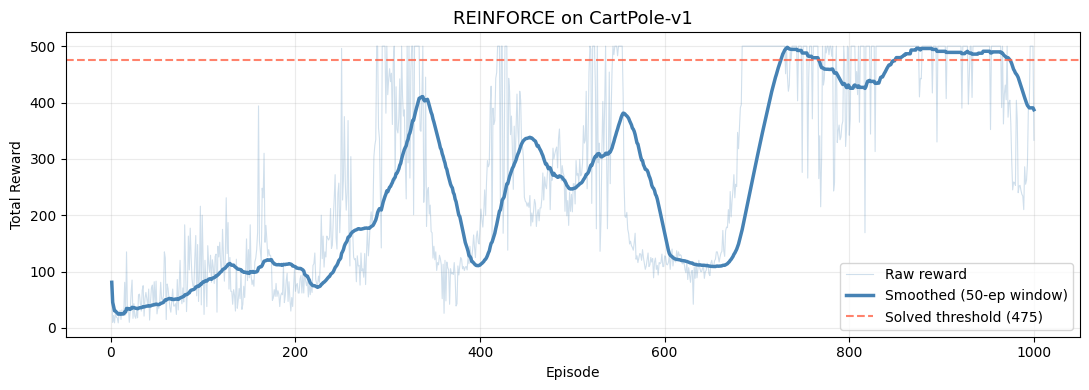

Saved → training_curve.png


In [8]:
def moving_average(values: list, window: int = 50) -> list:
    """Causal moving average — no look-ahead."""
    out = []
    for i in range(len(values)):
        lo = max(0, i - window + 1)
        out.append(float(np.mean(values[lo : i + 1])))
    return out


fig, ax = plt.subplots(figsize=(11, 4))
eps = range(1, len(episode_rewards) + 1)

ax.plot(eps, episode_rewards,
        alpha=0.25, color="steelblue", linewidth=0.8, label="Raw reward")
ax.plot(eps, moving_average(episode_rewards, 50),
        color="steelblue", linewidth=2.5, label="Smoothed (50-ep window)")
ax.axhline(475, color="tomato", linestyle="--", alpha=0.8,
           label="Solved threshold (475)")

ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
ax.set_title("REINFORCE on CartPole-v1", fontsize=13)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("training_curve.png", dpi=130)
plt.show()
print("Saved → training_curve.png")


---
## 8  Watch the Trained Agent

We run one **greedy** evaluation episode (always pick the most probable action,
no sampling) and record every rendered frame as a GIF.

Note: during training we *sampled* actions to encourage exploration.  For
evaluation we go greedy — we want to see the policy at its best.


In [9]:
def record_gif(
    policy:    PolicyNetwork,
    filename:  str = "agent.gif",
    max_steps: int = 500,
) -> str:
    """
    Run one greedy episode and save frames as an animated GIF.

    Uses render_mode='rgb_array' — no display needed (works headless on Colab).
    Each frame is a numpy array of shape (H, W, 3) uint8.
    imageio stacks them into (N, H, W, 3) and writes a GIF at ~30 fps.
    """
    env_rec = gym.make("CartPole-v1", render_mode="rgb_array")
    frames, total_reward = [], 0.0

    state, _ = env_rec.reset()
    done = False

    policy.eval()                          # disable dropout / batchnorm noise
    with torch.no_grad():                  # no gradients needed for evaluation
        while not done and len(frames) < max_steps:
            frame = env_rec.render()       # (H, W, 3) uint8
            frames.append(frame)

            state_t = torch.as_tensor(state, dtype=torch.float32, device=device)
            # state_t: (4,)

            probs  = policy(state_t)       # (2,) — action probabilities
            action = probs.argmax().item() # greedy: pick highest-prob action

            state, reward, terminated, truncated, _ = env_rec.step(action)
            done = terminated or truncated
            total_reward += reward

    env_rec.close()
    policy.train()                         # switch back to training mode

    frames_arr = np.stack(frames)          # (N, H, W, 3)
    # imageio v3 API: plugin='pillow' for GIF, duration in ms per frame (~30 fps)
    iio.imwrite(filename, frames_arr, plugin="pillow", loop=0, duration=33)

    print(f"Frames recorded : {len(frames)}")
    print(f"Total reward    : {total_reward:.0f}")
    print(f"GIF saved       → {filename}")
    return filename


gif_path = record_gif(policy)


Frames recorded : 420
Total reward    : 420
GIF saved       → agent.gif


### Result


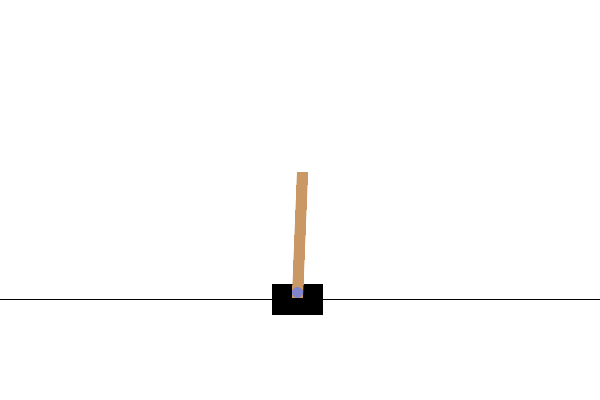

In [10]:
display(Image(gif_path))


---
## 9  Limitations of REINFORCE — What Comes Next

REINFORCE works but has two big weaknesses:

| Problem | Why it hurts | Fix |
|---------|-------------|-----|
| **High variance** | Returns from a full episode are noisy; gradients are all over the place | Subtract a *baseline* (value function) → **Actor-Critic** |
| **Sample inefficiency** | We throw away each episode after one gradient update | Importance sampling → **PPO** (reuse data with a clipped ratio) |

The series continues:

| Unit | Algorithm | Key idea |
|------|-----------|----------|
| **2** | **A3C + GAE** | Learn a value function as a baseline; Generalised Advantage Estimation controls the bias/variance trade-off |
| **3** | **PPO** | Clip the policy update ratio so we can take multiple gradient steps per batch of experience |
| **4** | **RLHF** | Replace the environment reward with a *learned reward model* trained from human preferences — this is how ChatGPT / Claude are fine-tuned |
| **5** | **GRPO** | Group Relative Policy Optimisation — the algorithm behind DeepSeek-R1's chain-of-thought reasoning |

→ [Back to the series](https://github.com/AliBuildsAI/rl-for-robotics-llms)
